<a href="https://colab.research.google.com/github/DSPL-B17/DSPL_hotelchainA/blob/main/Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


Load cleaned datsaets

In [36]:
train_df = pd.read_csv('/content/drive/MyDrive/DSPL/GCW/Data/Processed/train_cleaned.csv')
val_df = pd.read_csv('/content/drive/MyDrive/DSPL/GCW/Data/Processed/validation_cleaned.csv')
test_df = pd.read_csv('/content/drive/MyDrive/DSPL/GCW/Data/Processed/test_cleaned.csv')

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)


Train shape: (27499, 40)
Validation shape: (2749, 38)
Test shape: (4318, 36)


Define the target variable

In [13]:
target = "reservation_status"

Dropping unwanted columns

In [14]:
# Drop leakage columns from correlation analysis
drop_cols = [
    target,
    "Revenue_Loss",
    "Gross_Revenue",
    "Net_Revenue",
    "is_lost_booking",
    "booking_date",
    "expected_checkin",
    "expected_checkout"
]

X_train = train_df.drop(columns=[col for col in drop_cols if col in train_df.columns])
X_val = val_df.drop(columns=[col for col in drop_cols if col in val_df.columns])
X_test = test_df.drop(columns=[col for col in drop_cols if col in test_df.columns])

y_train = train_df[target]
y_val = val_df[target]

if target in test_df.columns:
    y_test = test_df[target]



Encoding the target

In [16]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)

if target in test_df.columns:
    y_test = le.transform(y_test)

num_classes = len(le.classes_)
print("Classes:", le.classes_)

Classes: [0 1 2]


One-hot encoding for features

In [17]:
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Encoded X_train shape:", X_train.shape)
print("Encoded X_val shape:", X_val.shape)
print("Encoded X_test shape:", X_test.shape)

Encoded X_train shape: (27499, 63)
Encoded X_val shape: (2749, 63)
Encoded X_test shape: (4318, 63)


Handle missing values

In [19]:
X_train = X_train.fillna(X_train.median())
X_val = X_val.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

Scaling features

In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


Building model function

In [21]:
def build_model(input_dim, num_classes):
    model = Sequential([
        Dense(128, activation="relu", input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

1. Training
2. Tuning using validation

In [22]:

model = build_model(X_train.shape[1], num_classes)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7687 - loss: 0.6862 - val_accuracy: 0.5857 - val_loss: 1.0193
Epoch 2/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7724 - loss: 0.6630 - val_accuracy: 0.5857 - val_loss: 1.0369
Epoch 3/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7724 - loss: 0.6572 - val_accuracy: 0.5857 - val_loss: 1.0430
Epoch 4/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7724 - loss: 0.6518 - val_accuracy: 0.5857 - val_loss: 1.0485
Epoch 5/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7724 - loss: 0.6505 - val_accuracy: 0.5857 - val_loss: 1.0441
Epoch 6/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7724 - loss: 0.6461 - val_accuracy: 0.5857 - val_loss: 1.0229


Accuracy & Loss curves

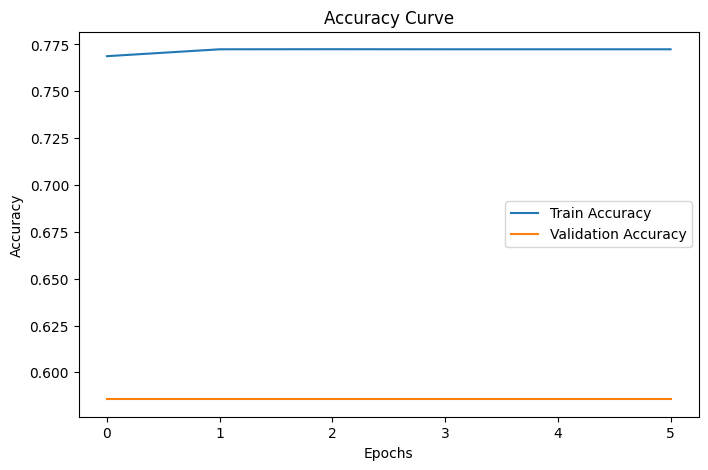

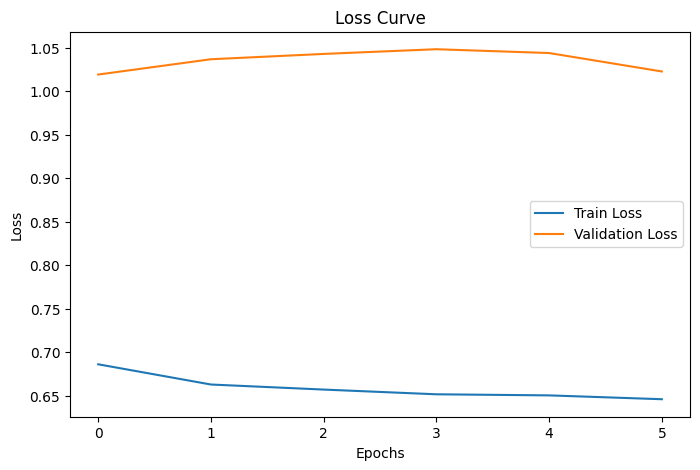

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Validation evaluation

In [30]:
val_pred_probs = model.predict(X_val)
val_pred = np.argmax(val_pred_probs, axis=1)

val_accuracy = accuracy_score(y_val, val_pred)
print("Validation Accuracy:", val_accuracy)

print("\nValidation Classification Report:")
class_names = [str(x) for x in le.classes_]
print(classification_report(y_val, val_pred, target_names=class_names, zero_division=0))

print("\nValidation Confusion Matrix:")
print(confusion_matrix(y_val, val_pred))

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Validation Accuracy: 0.5856675154601674

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       741
           1       0.59      1.00      0.74      1610
           2       0.00      0.00      0.00       398

    accuracy                           0.59      2749
   macro avg       0.20      0.33      0.25      2749
weighted avg       0.34      0.59      0.43      2749


Validation Confusion Matrix:
[[   0  741    0]
 [   0 1610    0]
 [   0  398    0]]


Confusion Matrix

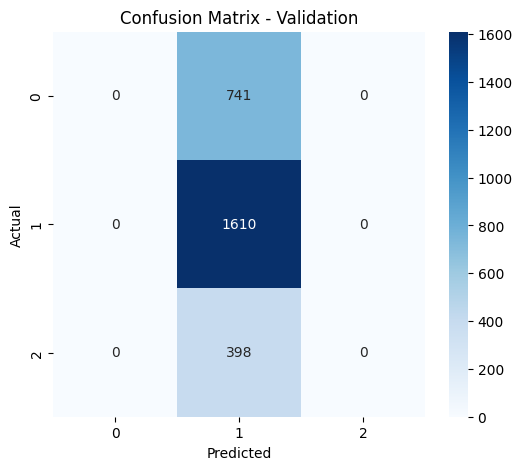

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, val_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Validation")
plt.show()

ROC, AUC using validation dataset


Validation ROC-AUC: 0.5189638864407763


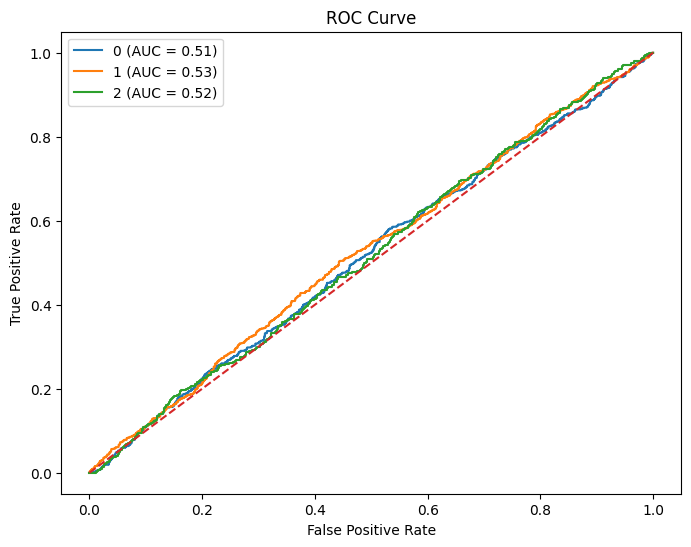

In [32]:
y_val_bin = label_binarize(y_val, classes=range(num_classes))

val_roc_auc = roc_auc_score(y_val_bin, val_pred_probs, multi_class="ovr")
print("\nValidation ROC-AUC:", val_roc_auc)

fpr = {}
tpr = {}
roc_auc_class = {}

plt.figure(figsize=(8, 6))

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], val_pred_probs[:, i])
    roc_auc_class[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f"{le.classes_[i]} (AUC = {roc_auc_class[i]:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


Training

In [33]:
final_model = build_model(X_train.shape[1], num_classes)

final_history = final_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7667 - loss: 0.6869
Epoch 2/50
 38/860 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7868 - loss: 0.6539

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7724 - loss: 0.6625
Epoch 3/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7724 - loss: 0.6565
Epoch 4/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7721 - loss: 0.6537
Epoch 5/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7724 - loss: 0.6488
Epoch 6/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7724 - loss: 0.6483
Epoch 7/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7723 - loss: 0.6468
Epoch 8/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7724 - loss: 0.6425
Epoch 9/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7724 - loss: 0.6422
Epoch 10/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7725 - loss: 0.6394
Epoch 11/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7727 - loss: 0.6392
Epoch 12/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7725 - loss: 0.6359
Epoch 13/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accurac

Final testing

In [34]:
test_pred_probs = final_model.predict(X_test)
test_pred = np.argmax(test_pred_probs, axis=1)


135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [35]:

if target in test_df.columns:
    test_accuracy = accuracy_score(y_test, test_pred)
    print("\nTest Accuracy:", test_accuracy)

    print("\nTest Classification Report:")
    print(classification_report(y_test, test_pred, target_names=le.classes_))

    print("\nTest Confusion Matrix:")
    print(confusion_matrix(y_test, test_pred))

    y_test_bin = label_binarize(y_test, classes=range(num_classes))
    test_roc_auc = roc_auc_score(y_test_bin, test_pred_probs, multi_class="ovr")
    print("\nTest ROC-AUC:", test_roc_auc)

else:
    test_pred_labels = le.inverse_transform(test_pred)

    predictions_df = pd.DataFrame({
        "Predicted_Reservation_Status": test_pred_labels
    })

    print("\nTest Predictions:")
    print(predictions_df.head())

    predictions_df.to_csv("nn_test_predictions.csv", index=False)
    print("\nPredictions saved as nn_test_predictions.csv")


Test Predictions:
   Predicted_Reservation_Status
0                             1
1                             1
2                             1
3                             1
4                             1

Predictions saved as nn_test_predictions.csv
